In [1]:
pip install pandas openpyxl matplotlib seaborn

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install xlrd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 1.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

Descargando dataset forzando la evasión de SSL (puede tomar unos segundos)...
✅ Descarga completa. Dimensiones del dataset: 30000 filas y 24 columnas.

--- Valores Nulos Totales ---
0 valores faltantes en toda la base.

--- Distribución de la Variable Objetivo ---
0 (Al corriente): 77.88%
1 (Default): 22.12%



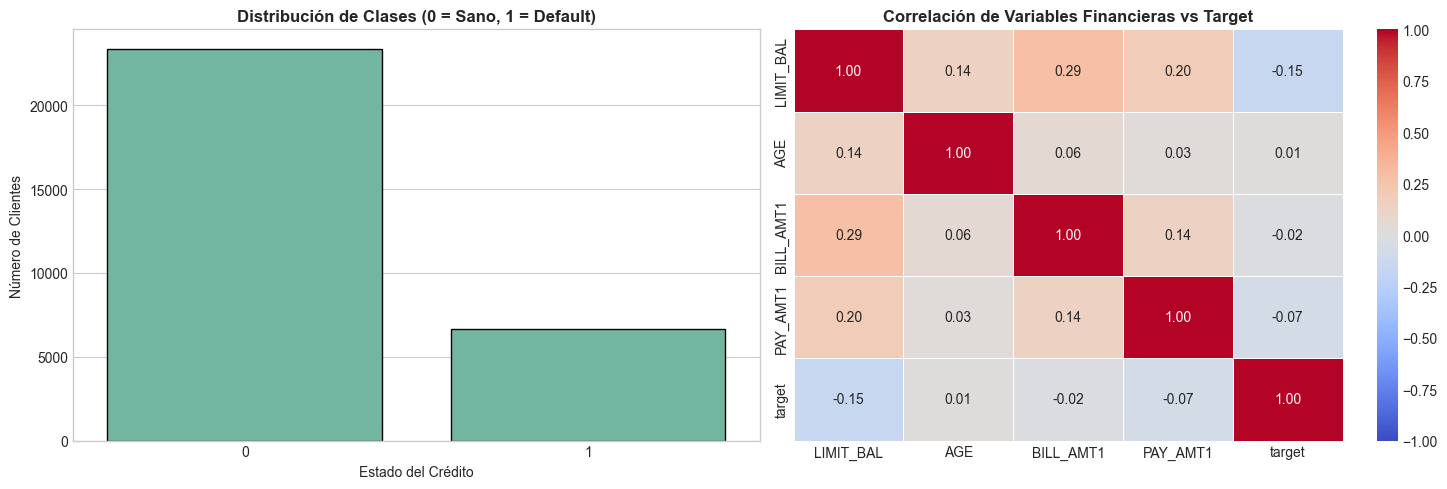

/var/folders/tj/d2cl5tvx3fbfm8vfnzbt4lhc0000gn/T/ipykernel_14193/3623176469.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PAY_1', y='target', data=df, errorbar=None, palette='Reds')


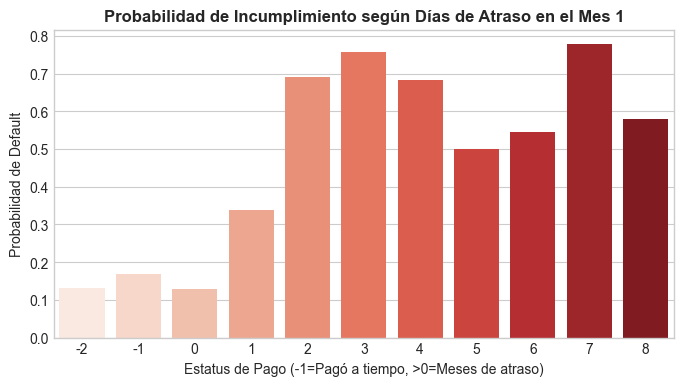

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import urllib3

# Silenciar las advertencias de conexión insegura en la consola
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Configuración visual para los gráficos en Jupyter
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# =====================================================================
# 1. EXTRACCIÓN FORZADA (BYPASS SSL)
# =====================================================================
print("Descargando dataset forzando la evasión de SSL (puede tomar unos segundos)...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

# Hacemos la petición HTTP ignorando los certificados (verify=False)
response = requests.get(url, verify=False)

# Leemos el archivo directamente desde la memoria de la descarga
df = pd.read_excel(io.BytesIO(response.content), header=1)

# Limpieza: Renombramos la variable objetivo y el primer mes
df = df.rename(columns={'default payment next month': 'target', 'PAY_0': 'PAY_1'})

# El ID no tiene valor predictivo, lo eliminamos
df = df.drop('ID', axis=1)

print(f"✅ Descarga completa. Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# =====================================================================
# 2. INSPECCIÓN BÁSICA
# =====================================================================
print("--- Valores Nulos Totales ---")
print(df.isnull().sum().max(), "valores faltantes en toda la base.\n")

# =====================================================================
# 3. ANÁLISIS DEL DESBALANCEO (VARIABLE OBJETIVO)
# =====================================================================
target_counts = df['target'].value_counts(normalize=True) * 100
print("--- Distribución de la Variable Objetivo ---")
print(f"0 (Al corriente): {target_counts[0]:.2f}%")
print(f"1 (Default): {target_counts[1]:.2f}%\n")

# =====================================================================
# 4. VISUALIZACIÓN EXPLORATORIA
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: El desbalanceo de clases
sns.countplot(x='target', data=df, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribución de Clases (0 = Sano, 1 = Default)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
axes[0].set_xlabel('Estado del Crédito')

# Gráfico 2: Matriz de Correlación (Subconjunto de variables)
cols_correlacion = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'target']
corr_matrix = df[cols_correlacion].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlación de Variables Financieras vs Target', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# 5. ANÁLISIS DE COMPORTAMIENTO (BEHAVIORAL)
# =====================================================================
plt.figure(figsize=(8, 4))
sns.barplot(x='PAY_1', y='target', data=df, errorbar=None, palette='Reds')
plt.title('Probabilidad de Incumplimiento según Días de Atraso en el Mes 1', fontweight='bold')
plt.xlabel('Estatus de Pago (-1=Pagó a tiempo, >0=Meses de atraso)')
plt.ylabel('Probabilidad de Default')
plt.show()

In [10]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Entrenando el modelo de Máxima Verosimilitud con pesos de clase...

--- REPORTE DE CLASIFICACIÓN (Datos de Prueba) ---
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC Score: 0.7081



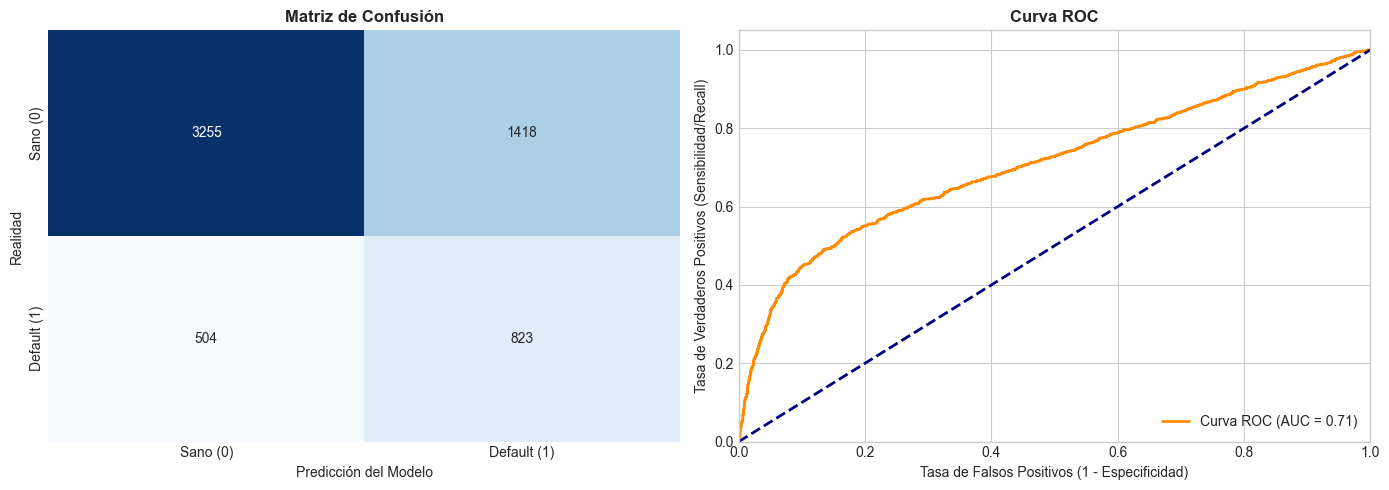

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PREPARACIÓN DE DATOS (X e Y)
# =====================================================================
# Separamos las variables explicativas (X) de la variable objetivo (y)
X = df.drop('target', axis=1)
y = df['target']

# Dividimos en Entrenamiento (80%) y Prueba (20%)
# stratify=y asegura que la misma proporción de defaults se mantenga en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =====================================================================
# 2. ESCALAMIENTO (ESTANDARIZACIÓN)
# =====================================================================
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar 'data leakage'
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 3. ENTRENAMIENTO DEL MODELO (REGRESIÓN LOGÍSTICA CON PESOS)
# =====================================================================
print("Entrenando el modelo de Máxima Verosimilitud con pesos de clase...")
# class_weight='balanced' ajusta automáticamente los pesos inversamente proporcionales a las frecuencias
modelo_pd = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_pd.fit(X_train_scaled, y_train)

# =====================================================================
# 4. PREDICCIONES Y EVALUACIÓN
# =====================================================================
# Predecimos la clase (0 o 1)
y_pred = modelo_pd.predict(X_test_scaled)

# Predecimos la PROBABILIDAD continua (para el cálculo del ROC-AUC y el ECL final)
# predict_proba devuelve dos columnas: prob. de ser 0 y prob. de ser 1. Tomamos la segunda.
y_prob = modelo_pd.predict_proba(X_test_scaled)[:, 1]

print("\n--- REPORTE DE CLASIFICACIÓN (Datos de Prueba) ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# =====================================================================
# 5. VISUALIZACIÓN DE RESULTADOS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Realidad')
axes[0].set_xticklabels(['Sano (0)', 'Default (1)'])
axes[0].set_yticklabels(['Sano (0)', 'Default (1)'])

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad/Recall)')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [12]:
# =====================================================================
# 6. CÁLCULO DE LA PÉRDIDA ESPERADA (ECL) DEL PORTAFOLIO
# =====================================================================
# Recuperamos el saldo original de los clientes en nuestro set de prueba
# X_test conservó los índices originales del DataFrame
EAD = X_test['BILL_AMT1'].clip(lower=0) # Evitamos saldos negativos

# Supuesto de LGD para tarjetas de crédito sin colateral (75%)
LGD = 0.75 

# Calculamos el ECL individual
# ECL = PD * LGD * EAD
ecl_individual = y_prob * LGD * EAD

# Sumamos para obtener la reserva total requerida para este segmento
reserva_total = ecl_individual.sum()
exposicion_total = EAD.sum()

print("--- CÁLCULO DE RESERVAS IFRS 9 / BASILEA ---")
print(f"Exposición Total (EAD) del set de prueba: ${exposicion_total:,.2f}")
print(f"Reserva Total Requerida (ECL):            ${reserva_total:,.2f}")
print(f"Porcentaje de Cobertura:                  {(reserva_total/exposicion_total)*100:.2f}%")

--- CÁLCULO DE RESERVAS IFRS 9 / BASILEA ---
Exposición Total (EAD) del set de prueba: $310,376,297.00
Reserva Total Requerida (ECL):            $101,626,828.79
Porcentaje de Cobertura:                  32.74%
